# Steady-State Error (SSE)

The **steady-state error (SSE)** is the difference between the reference input and the system output after all transient effects have vanished. It is a key measure of the accuracy of a control system.

## Definition

$
e_{ss}=\lim_{t\rightarrow\infty}e(t)
$

where

$
e(t)=r(t)-c(t),
$

- $\(r(t)\)$: Reference input
- $\(c(t)\)$: System output
- $\(e(t)\)$: Error signal

## Final Value Theorem

Using the Final Value Theorem,

$
e_{ss}
=
\lim_{t\rightarrow\infty}e(t)
=
\lim_{s\rightarrow0}sE(s),
$

provided that all poles of \(sE(s)\) lie in the left-half of the \(s\)-plane (except possibly a simple pole at the origin).

## Error Transfer Function

For a **unity feedback** control system,

$
E(s)=\frac{R(s)}{1+G(s)},
$

where:

- \(R(s)\): Input (reference)
- \(G(s)\): Open-loop transfer function
- \(E(s)\): Error transfer function

Hence, the steady-state error is

$
\boxed{
e_{ss}
=
\lim_{s\rightarrow0}
s\left(\frac{R(s)}{1+G(s)}\right)
}
$

This expression forms the basis for determining the steady-state error for different standard inputs such as step, ramp, and parabolic signals.

In [1]:
import numpy as np
import sympy as sp
from control import matlab as mt
import scienceplots 
import matplotlib.pyplot as plt

plt.style.use(['science','no-latex'])

In [16]:
from sympy.abc import s,t

In [17]:
num=[1]
den=[1,0,1]
sys=mt.tf(num,den)

In [18]:
sys

TransferFunction(
array([1]),
array([1, 0, 1]),
outputs=1, inputs=1)

In [19]:
response=mt.step(sys)

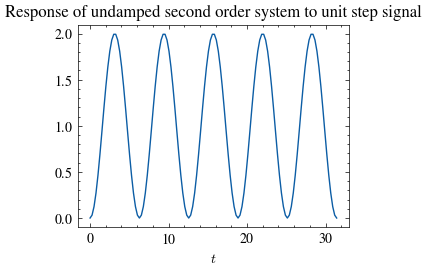

In [20]:
plt.plot(response[1],response[0])
plt.title("Response of undamped second order system to unit step signal")
plt.xlabel("$t$")
plt.show()

In [21]:
mt.stepinfo(sys)

{'RiseTime': 1.0053096491487339,
 'SettlingTime': nan,
 'SettlingMin': 1.2923689896027213e-15,
 'SettlingMax': 1.9921147013144775,
 'Overshoot': 99.21147013144775,
 'Undershoot': 0.0,
 'Peak': 1.9921147013144775,
 'PeakTime': 3.0159289474462017,
 'SteadyStateValue': 1.0}

In [31]:
y=1/s-s/(1+s**2)

In [32]:
y

-s/(s**2 + 1) + 1/s

In [33]:
Y=sp.integrals.inverse_laplace_transform(y,s,t)

In [34]:
Y

-cos(t)*Heaviside(t) + Heaviside(t)